In [1]:
# ===============================
# DATA EXTRACTION SECTION
# Fetch data from SQL database
# ===============================

import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
from sqlalchemy import create_engine

In [4]:
engine = create_engine(
    "mssql+pyodbc://DESKTOP-CH6UADE\\SQLEXPRESS/ecommerce_project?driver=ODBC+Driver+17+for+SQL+Server"
)

In [5]:
# First query select from orders table

query = "SELECT * FROM orders"

In [6]:
orders = pd.read_sql(query,engine)

In [7]:
# Second query select from Customers table

query2 = "SELECT * FROM customers"

In [8]:
customers = pd.read_sql(query2,engine)

In [9]:
# ===============================
# DATA INSPECTION
# Inspecting both dataset
# ===============================

orders.head()

,Order_ID,Customer_ID,Product_ID,Order_Date,Quantity,Price,Payment_Method,Delivery_Status,Total_Amount
0,100000,1940,109,2024-02-11,2,44005,NetBanking,Delivered,88010
1,100001,7379,175,2025-07-22,2,41355,UPI,Not Delivered,82710
2,100002,658,180,2024-08-23,5,47613,Cash,Delivered,238065
3,100003,3668,145,2025-06-03,4,25531,Cash,Not Delivered,102124
4,100004,1054,189,2024-08-02,4,28894,NetBanking,Not Delivered,115576


In [10]:
customers.head()

,Customer_ID,Customer_Name,City,Signup_Date
0,1,Customer_1,Pune,2024-09-09
1,2,Customer_2,Jaipur,2023-01-21
2,3,Customer_3,Chennai,2023-03-05
3,4,Customer_4,Pune,2023-06-14
4,5,Customer_5,Bangalore,2023-01-27


In [11]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Order_ID         50000 non-null  int64 
 1   Customer_ID      50000 non-null  int64 
 2   Product_ID       50000 non-null  int64 
 3   Order_Date       50000 non-null  object
 4   Quantity         50000 non-null  int64 
 5   Price            50000 non-null  int64 
 6   Payment_Method   49500 non-null  object
 7   Delivery_Status  49700 non-null  object
 8   Total_Amount     50000 non-null  int64 
dtypes: int64(6), object(3)
memory usage: 3.4+ MB


In [12]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Customer_ID    8000 non-null   int64 
 1   Customer_Name  8000 non-null   object
 2   City           7800 non-null   object
 3   Signup_Date    8000 non-null   object
dtypes: int64(1), object(3)
memory usage: 250.1+ KB


In [13]:
# ===============================
# CHECKING MISSING VALUE
# ===============================

orders.isnull().sum()

Order_ID             0
Customer_ID          0
Product_ID           0
Order_Date           0
Quantity             0
Price                0
Payment_Method     500
Delivery_Status    300
Total_Amount         0
dtype: int64

In [14]:
customers.isnull().sum()

Customer_ID        0
Customer_Name      0
City             200
Signup_Date        0
dtype: int64

In [15]:
# Filling Null values in order table with unknown

orders['Payment_Method'] = orders['Payment_Method'].fillna('Unknown')

In [16]:
orders['Delivery_Status'] = orders['Delivery_Status'].fillna('Unknown')

In [17]:
# Filling Null values in customers table with unknown

customers['City'] = customers['City'].fillna('Unknown')

In [18]:
# ===============================
# CONVERTING DATE COLUMNS
# ===============================

orders['Order_Date'] = pd.to_datetime(orders['Order_Date'])

In [19]:
customers['Signup_Date'] = pd.to_datetime(customers['Signup_Date'])

In [20]:
# ===============================
# MERGING TABLES
# ===============================

df = pd.merge(
    orders,
    customers,
    on="Customer_ID",
    how="left"
)

In [21]:
df.head()

,Order_ID,Customer_ID,Product_ID,Order_Date,Quantity,Price,Payment_Method,Delivery_Status,Total_Amount,Customer_Name,City,Signup_Date
0,100000,1940,109,2024-02-11,2,44005,NetBanking,Delivered,88010,Customer_1940,Pune,2024-04-21
1,100001,7379,175,2025-07-22,2,41355,UPI,Not Delivered,82710,Customer_7379,Chennai,2024-06-23
2,100002,658,180,2024-08-23,5,47613,Cash,Delivered,238065,Customer_658,Bangalore,2024-06-03
3,100003,3668,145,2025-06-03,4,25531,Cash,Not Delivered,102124,Customer_3668,Kolkata,2025-03-13
4,100004,1054,189,2024-08-02,4,28894,NetBanking,Not Delivered,115576,Customer_1054,Pune,2023-08-04


In [22]:
# ===============================
# ANALYSIS
# ===============================

# Revenue by City
city_revenue = df.groupby('City')['Total_Amount'].sum().sort_values(ascending=False)

In [23]:
city_revenue

City
Delhi        469768178
Hyderabad    469671835
Jaipur       468728702
Chennai      463809886
Pune         462950365
Kolkata      458119376
Bangalore    449769595
Mumbai       438049239
Unknown       97017522
Name: Total_Amount, dtype: int64

In [24]:
# Payment method

payment_mode = df.groupby('Payment_Method')['Total_Amount'].sum()

In [25]:
payment_mode

Payment_Method
Card          914929150
Cash          941018439
NetBanking    943957314
UPI           938283994
Unknown        39695801
Name: Total_Amount, dtype: int64

In [26]:
# Monthly revenue trend

monthly_revenue = df.groupby(df['Order_Date'].dt.to_period('M'))['Total_Amount'].sum()

In [27]:
monthly_revenue

Order_Date
2024-01    198810384
2024-02    182832559
2024-03    198186566
2024-04    182362776
2024-05    195611928
2024-06    189527385
2024-07    193028530
2024-08    196557483
2024-09    184875260
2024-10    201262118
2024-11    186892064
2024-12    192736534
2025-01    189337621
2025-02    174132900
2025-03    198326406
2025-04    189917012
2025-05    194957513
2025-06    189911593
2025-07    188170804
2025-08    150447262
Freq: M, Name: Total_Amount, dtype: int64

In [28]:
# Pivot Table

pivot = pd.pivot_table(
    df,
    index='City',
    columns='Payment_Method',
    values='Total_Amount',
    aggfunc='sum'
)

In [29]:
pivot

Payment_Method,Card,Cash,NetBanking,UPI,Unknown
City,,,,,
Bangalore,114105045,109320705,109011971,112587633,4744241
Chennai,106453566,119608520,117944030,115103874,4699896
Delhi,113937997,118154433,116859838,115348773,5467137
Hyderabad,109925814,119514238,118643710,116579056,5009017
Jaipur,111008503,117352414,121891935,114345931,4129919
Kolkata,109244607,113768129,111152015,119400787,4553838
Mumbai,108618826,109500761,105468769,109417053,5043830
Pune,116988988,111324992,118504493,111405552,4726340
Unknown,24645804,22474247,24480553,24095335,1321583


In [30]:
# Cross Tab

cross_tab = pd.crosstab(df['City'],df['Delivery_Status'])

In [31]:
cross_tab

Delivery_Status,Delivered,Not Delivered,Returned,Unknown
City,,,,
Bangalore,1947,1949,1983,28
Chennai,2068,1986,2092,44
Delhi,2038,1999,2059,43
Hyderabad,2027,2020,2091,32
Jaipur,2106,1991,2066,33
Kolkata,2022,2015,1994,35
Mumbai,1940,1996,1929,37
Pune,2050,2020,2051,37
Unknown,407,435,419,11


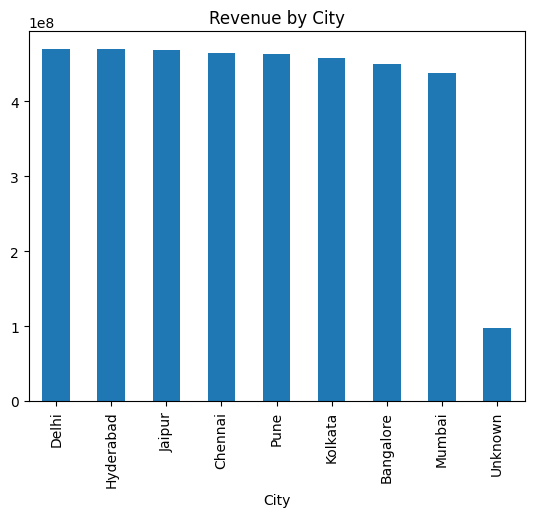

In [32]:
# ===============================
# Visualization
# ===============================

city_revenue.plot(kind='bar')
plt.title('Revenue by City')
plt.show()


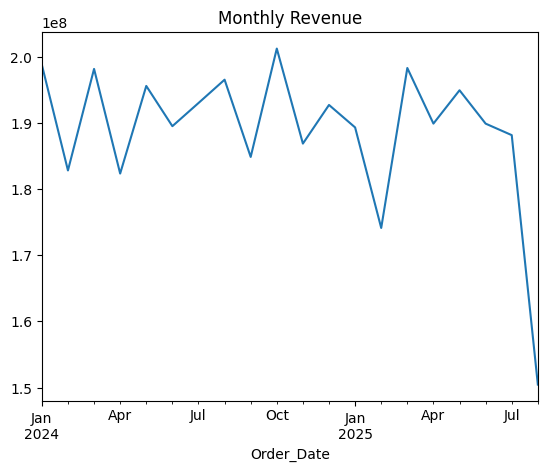

In [33]:
monthly_revenue.plot(kind='line')
plt.title('Monthly Revenue')
plt.show()

In [41]:
# ===============================
# Exporting Processed Data
# ===============================

processed = df.to_csv(r'C:\Users\VANSH ARORA\OneDrive\Desktop\ecommerce_project\ecommerce-data-analytics-project\data\processed\python_analysis.csv')
print('File Sucessfully Saved')

File Sucessfully Saved
